# Artificial Intelligence Homework 2: CNN Competition

## Problem Statement

### Context

This assignment is a mini AI competition. Each group (Same group from Project) will design
and train a custom Convolutional Neural Network (CNN) to classify images from the subset
of Tiny ImageNet dataset. Your model will be trained and validated using the data provided.
The instructor will test your model on a hidden (unseen) 20% test set that you will not have
access to. Your final score and ranking will depend on your model's accuracy on this unseen
test set.


### Objective

The aim of this project is to design and train a Sequential CNN (from scratch) that performs accurate classification on
Tiny ImageNet data.

### Data Dictionary

???

## Importing necessary libraries

In [1]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import math
import cv2

# Tensorflow modules
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization,Activation,GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam,SGD
from sklearn import preprocessing
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Display images using OpenCV
from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
tf.keras.utils.set_random_seed(812)

## Loading the dataset

In [2]:
# Uncomment and run the below code if you are using google colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# loading the dataset
import pickle
train = pickle.load(open("/content/drive/MyDrive/train-70_.pkl", "rb"))
val = pickle.load(open("/content/drive/MyDrive/validation-10_.pkl", "rb"))

In [4]:
# separating the images and labels for train and val respectively
images_train = train['images']
labels_train = train['labels']

images_val = val['images']
labels_val = val['labels']


## Data Overview

### Understand the shape of the dataset

In [5]:
# Showing the shape of each key in the dictionary; redundant once we write the dictionary
for key in train:
  print(key, ": ", len(train[key]), sep="")

images: 5775
labels: 5775
class_names: 15
all_classes: 200


In [6]:
# Seeing there are 5775 images of size 64 by 64 with 3 color channels in training and 825 in val
print(images_train.shape)
print(images_val.shape)

(5775, 64, 64, 3)
(825, 64, 64, 3)


In [7]:
def plot_images(labels,classes):
  class_indices = {key:[] for key in classes}                                     # Unique classes turned into dictionary keys

  for i, label in enumerate(labels):                                              # Setting every image/label index to its class key
    if label in class_indices:
      class_indices[label].append(i)

  rows = 3                                                                        # Defining number of rows=3
  cols = 5                                                                        # Defining number of columns=5
  fig = plt.figure(figsize=(11, 9))                                               # Defining the figure size to 11x9
  for plot_num, key in enumerate(class_indices, start = 1):
    random_index = random.choice(class_indices[key])                              # Generating a random index for an image of the class
    ax = fig.add_subplot(rows, cols, plot_num)                                    # Adding subplots
    ax.imshow(images_train[random_index, :])                                            # Plotting the image
    ax.set_title("["+str(key)+"]")                                                # Getting and displaying the class number for the image
  plt.show()                                                                      # Showing the completed plot

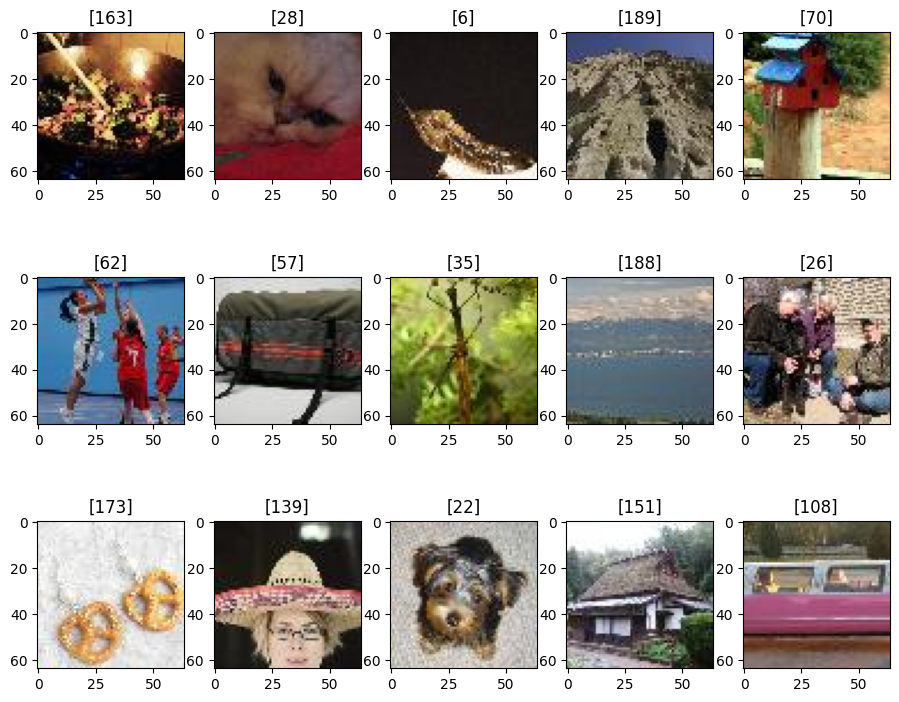

In [8]:
plot_images(labels_train,train['class_names'])

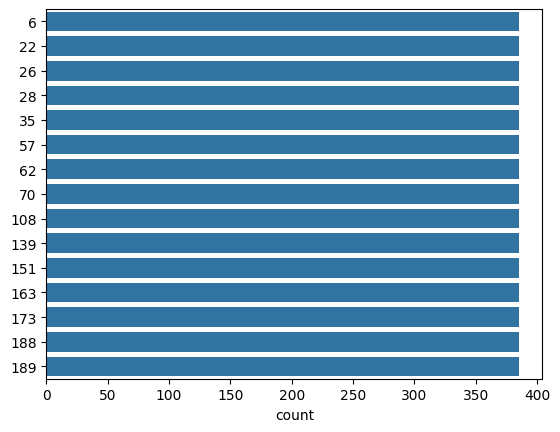

In [9]:
# Creating a small countplot of our classes to see if they're imbalanced
sns.countplot(y=labels_train)
plt.xticks(rotation='horizontal');

## Data Pre-Processing

### Data Normalization

In [10]:
# Scalling is necessary because neural networks work best with values of 0 to 1
X_train = images_train.astype('float32') / 255.0
X_val = images_val.astype('float32') / 255.0

### Encode the target labels

In [11]:
# LabelBinarizer is a preprocessing utility in sklearn.preprocessing
# that converts categorical labels into a binary (one-hot) representation. It is
# useful for transforming multi-class labels into a format suitable for models
# that require numerical input.

# Used here so that the 15 classes can be represented in binary.
enc = LabelBinarizer()
y_train = enc.fit_transform(labels_train)
y_val = enc.transform(labels_val)

## Model Building

### Utility Functions

In [12]:
# Initialize empty DataFrame to store all model results
model_results = pd.DataFrame(columns=["Model", "Accuracy", "Recall", "Precision", "F1 Score", "Val Loss"])

# Utility function to help measure models' performance
def model_performance_classification(name, model, history, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    name: Name of the model/experiment (string)
    model: classifier
    history: keras history
    predictors: independent variables
    target: dependent variable
    """

    pred = model.predict(predictors).argmax(axis=1)

    target = target.argmax(axis=1)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='weighted')  # to compute Recall
    precision = precision_score(target, pred, average='weighted')  # to compute Precision
    f1 = f1_score(target, pred, average='weighted')  # to compute F1-score

    if history is None:
      val_loss = None
    else:
      val_loss = history.history['val_loss'][-1] # to get Val Loss from history

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Model": name, "Accuracy": acc, "Recall": recall,
                            "Precision": precision, "F1 Score": f1,
                            "Val Loss": val_loss},index=[0],)

    global model_results
    model_results = pd.concat([model_results, df_perf], ignore_index=True)
    model_results = model_results.drop_duplicates()

    return df_perf

In [13]:
# Another utility function, for confusion matrices
def plot_confusion_matrix(model,predictors,target,save_path=None):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    save_path: path of location you want image saved
    """

    pred = model.predict(predictors).argmax(axis=1)

    target = target.argmax(axis=1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )

    if save_path:
        plt.savefig(save_path, dpi=f.get_dpi())

    plt.show()

In [14]:
# Utility function to visualize the model accuracy and loss curves
def plot(history, metric, save_path=None):
    """
    Plot training and validation curves for loss or accuracy.

    Parameters:
    - history: Keras History object.
    - metric: 'loss' or 'accuracy'
    - save_path: path of location you want image saved
    """
    plt.figure(figsize=(8, 5))
    plt.plot(history.history[metric], label='Train')
    plt.plot(history.history['val_' + metric], label='Validation')
    plt.title(f'Model {metric.capitalize()}')
    plt.xlabel('Epoch')
    plt.ylabel(metric.capitalize())
    plt.legend(loc='upper right')
    plt.grid(True)

    if save_path:
        plt.savefig(save_path, dpi=plt.gcf().get_dpi())

    plt.show()

### Normal Neural Networks as Basline Models

#### Neural Network Using SGD

In [15]:
# 1. Define the model architecture
model_sgd = Sequential() # Initializing model
model_sgd.add(Flatten(input_shape=(64, 64, 3))) # Input layer
model_sgd.add(Dense(128, activation='relu'))
model_sgd.add(Dense(64, activation='relu'))

model_sgd.add(Dense(15, activation='softmax')) # Output layer

# 2. Compile the model with SGD optimizer
model_sgd.compile(
    optimizer=SGD(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Train the model
history_sgd = model_sgd.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.1075 - loss: 2.6741 - val_accuracy: 0.1515 - val_loss: 2.6140
Epoch 2/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1631 - loss: 2.5900 - val_accuracy: 0.1770 - val_loss: 2.5479
Epoch 3/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1820 - loss: 2.5357 - val_accuracy: 0.2012 - val_loss: 2.4966
Epoch 4/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1990 - loss: 2.4909 - val_accuracy: 0.2170 - val_loss: 2.4566
Epoch 5/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2190 - loss: 2.4525 - val_accuracy: 0.2242 - val_loss: 2.4252
Epoch 6/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2289 - loss: 2.4190 - val_accuracy: 0.2327 - val_loss: 2.4002
Epoch 7/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2424 - loss: 2.3897 - val_accuracy: 0.2400 - val_loss: 2.3763
Epoch 8/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2533 - loss: 2.3638 - val_accuracy: 

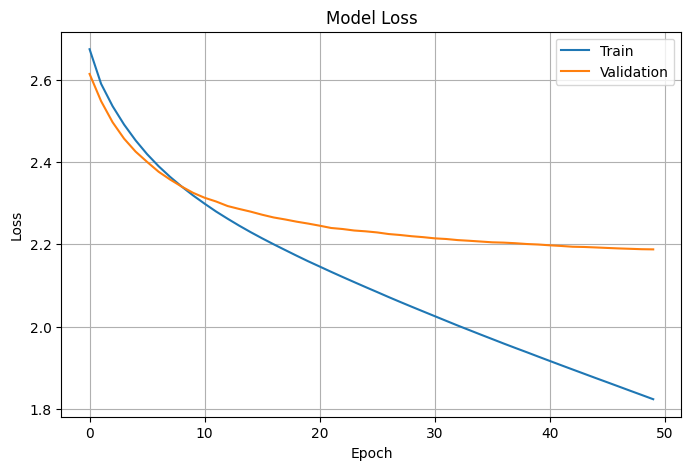

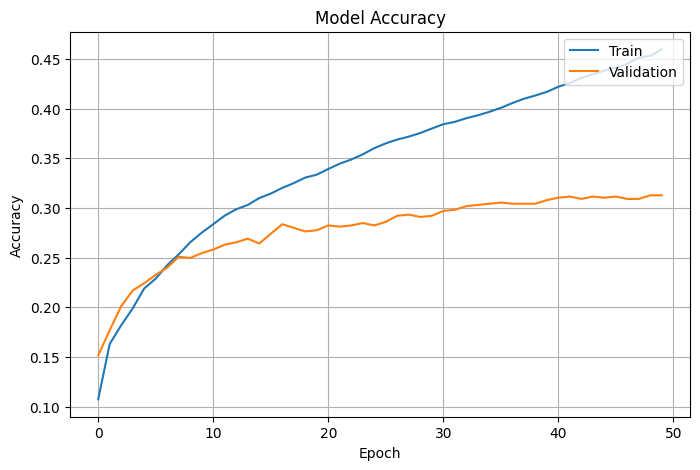

In [16]:
# 4 Plotting the loss and accuracy curves
plot(history_sgd, 'loss')
plot(history_sgd, 'accuracy')

In [17]:
# 5. Computing performance tables
model_sgd_train_perf = model_performance_classification("MLP Train", model_sgd, None, X_train, y_train)
display(model_sgd_train_perf)

model_sgd_val_perf =  model_performance_classification("MLP Val", model_sgd, history_sgd, X_val, y_val)
display(model_sgd_val_perf)

181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


,Model,Accuracy,Recall,Precision,F1 Score,Val Loss
0,MLP Train,0.467706,0.467706,0.483695,0.459295,None


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


,Model,Accuracy,Recall,Precision,F1 Score,Val Loss
0,MLP Val,0.312727,0.312727,0.311369,0.300913,2.187558


In [18]:
# 6. Printing all model results
display(model_results)

,Model,Accuracy,Recall,Precision,F1 Score,Val Loss
0,MLP Train,0.467706,0.467706,0.483695,0.459295,NaN
1,MLP Val,0.312727,0.312727,0.311369,0.300913,2.187558


#### Neural Network Using Adam

In [19]:
# 1. Define the model architecture
model_adam = Sequential()
model_adam.add(Flatten(input_shape=(64, 64, 3))) # Input layer

model_adam.add(Dense(128, use_bias=False))
model_adam.add(BatchNormalization())  # Added BatchNorm
model_adam.add(Activation('relu'))
model_adam.add(Dropout(.3)) # Added Dropout

model_adam.add(Dense(64, use_bias=False))
model_adam.add(BatchNormalization())
model_adam.add(Activation('relu'))
model_adam.add(Dropout(.5))

model_adam.add(Dense(32, use_bias=False)) # Added layer to increase depth
model_adam.add(BatchNormalization())
model_adam.add(Activation('relu'))
model_adam.add(Dropout(.5))

model_adam.add(Dense(15, activation='softmax')) # Output layer

# 2. Compile the model with Adam optimizer
model_adam.compile(
    optimizer=Adam(learning_rate=5e-5), # Smaller learning rate
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Train the model
history_adam = model_adam.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.0748 - loss: 3.1394 - val_accuracy: 0.1200 - val_loss: 2.6813
Epoch 2/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0866 - loss: 3.0388 - val_accuracy: 0.1576 - val_loss: 2.5995
Epoch 3/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0951 - loss: 2.9922 - val_accuracy: 0.1661 - val_loss: 2.5841
Epoch 4/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1079 - loss: 2.9072 - val_accuracy: 0.1855 - val_loss: 2.5771
Epoch 5/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1122 - loss: 2.8850 - val_accuracy: 0.1879 - val_loss: 2.5379
Epoch 6/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1096 - loss: 2.8449 - val_accuracy: 0.1939 - val_loss: 2.5221
Epoch 7/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1203 - loss: 2.8101 - val_accuracy: 0.2121 - val_loss: 2.5232
Epoch 8/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1297 - loss: 2.7775 - val_accuracy: 

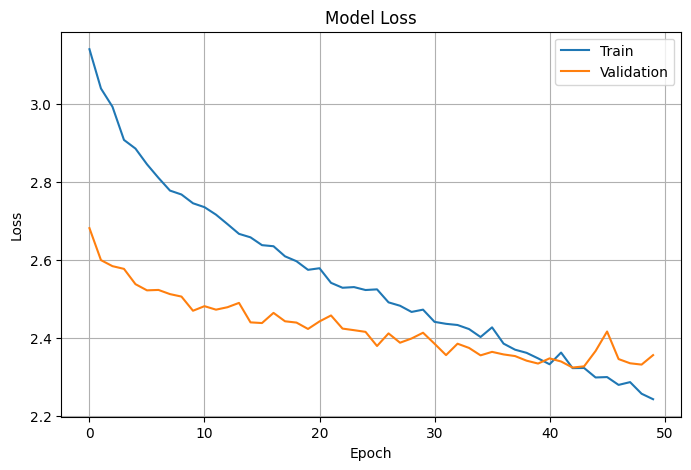

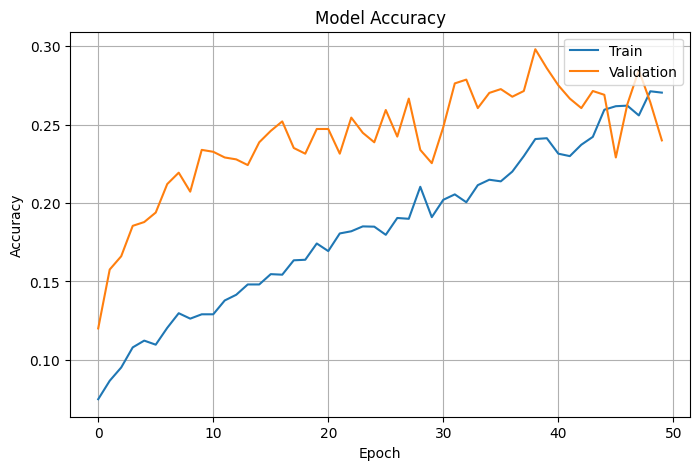

In [20]:
# 4. Plotting the loss and accuracy curves
plot(history_adam, 'loss', save_path=None)
plot(history_adam, 'accuracy', save_path=None)

In [21]:
# 5. Computing performance tables
model_adam_train_perf = model_performance_classification("MLP Train Adam", model_adam, None, X_train, y_train)
display(model_adam_train_perf)

model_adam_val_perf =  model_performance_classification("MLP Val Adam", model_adam, history_adam, X_val, y_val)
display(model_adam_val_perf)

181/181 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step


,Model,Accuracy,Recall,Precision,F1 Score,Val Loss
0,MLP Train Adam,0.401212,0.401212,0.52315,0.37046,None


26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


,Model,Accuracy,Recall,Precision,F1 Score,Val Loss
0,MLP Val Adam,0.24,0.24,0.25297,0.198768,2.356306


In [22]:
# 6. Printing all model results
display(model_results)

,Model,Accuracy,Recall,Precision,F1 Score,Val Loss
0,MLP Train,0.467706,0.467706,0.483695,0.459295,NaN
1,MLP Val,0.312727,0.312727,0.311369,0.300913,2.187558
2,MLP Train Adam,0.401212,0.401212,0.523150,0.370460,NaN
3,MLP Val Adam,0.240000,0.240000,0.252970,0.198768,2.356306


### Convolutional Neural Networks

#### Basic CNN Using SGD

In [25]:
# 1. Define the model architecture
model_cnn_sgd = Sequential() # Initializing model

# 2. Convulutional layers
model_cnn_sgd.add(Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)))
model_cnn_sgd.add(MaxPooling2D(pool_size=(2,2)))
model_cnn_sgd.add(Conv2D(64, (3,3), activation='relu'))
model_cnn_sgd.add(MaxPooling2D(pool_size=(2,2)))
model_cnn_sgd.add(Conv2D(128, (3,3), activation='relu'))

# 3. Normal Neural Network layers
model_cnn_sgd.add(Flatten())
model_cnn_sgd.add(Dense(128, activation='relu'))
model_cnn_sgd.add(Dense(64, activation='relu'))

model_cnn_sgd.add(Dense(15, activation='softmax')) # Output layer

# 4. Compile the model with SGD optimizer
model_cnn_sgd.compile(
    optimizer=SGD(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Train the model
hist_cnn_sgd = model_cnn_sgd.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
181/181 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.0753 - loss: 2.7038 - val_accuracy: 0.0703 - val_loss: 2.6982
Epoch 2/100
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0739 - loss: 2.6967 - val_accuracy: 0.0739 - val_loss: 2.6918
Epoch 3/100
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0800 - loss: 2.6899 - val_accuracy: 0.0812 - val_loss: 2.6845
Epoch 4/100
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0861 - loss: 2.6822 - val_accuracy: 0.0873 - val_loss: 2.6759
Epoch 5/100
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0961 - loss: 2.6725 - val_accuracy: 0.0958 - val_loss: 2.6646
Epoch 6/100
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1046 - loss: 2.6600 - val_accuracy: 0.1030 - val_loss: 2.6499
Epoch 7/100
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1169 - loss: 2.6444 - val_accuracy: 0.1139 - val_loss: 2.6318
Epoch 8/100
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1276 - loss: 2.6252 - val_acc

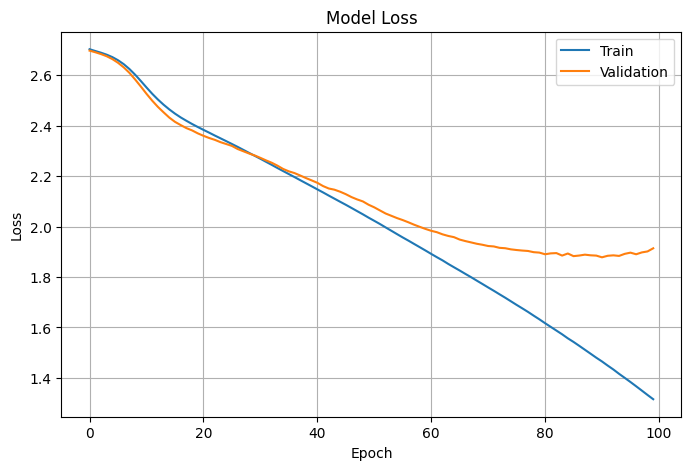

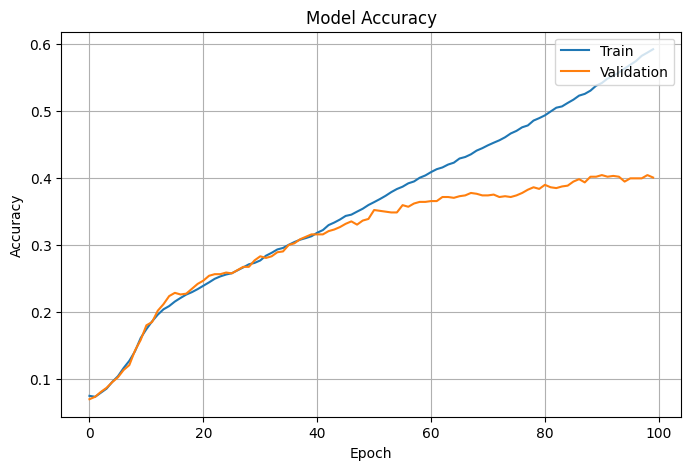

In [26]:
# 6. Plotting the loss and accuracy curves
plot(hist_cnn_sgd, 'loss', save_path=None)
plot(hist_cnn_sgd, 'accuracy', save_path=None)

In [ ]:
# 7. Computing performance tables
model_adam_train_perf = model_performance_classification("CNN Train Basic SGD", model_cnn_sgd, None, X_train, y_train)
display(model_adam_train_perf)

model_adam_val_perf =  model_performance_classification("CNN Val Basic SGD", model_cnn_sgd, hist_cnn_sgd, X_val, y_val)
display(model_adam_val_perf)

181/181 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step


,Model,Accuracy,Recall,Precision,F1 Score,Val Loss
0,MLP Train Adam,0.401212,0.401212,0.52315,0.37046,None


26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


,Model,Accuracy,Recall,Precision,F1 Score,Val Loss
0,MLP Val Adam,0.24,0.24,0.25297,0.198768,2.356306


In [ ]:
# 8. Printing all model results
display(model_results)

,Model,Accuracy,Recall,Precision,F1 Score,Val Loss
0,MLP Train,0.467706,0.467706,0.483695,0.459295,NaN
1,MLP Val,0.312727,0.312727,0.311369,0.300913,2.187558
2,MLP Train Adam,0.401212,0.401212,0.523150,0.370460,NaN
3,MLP Val Adam,0.240000,0.240000,0.252970,0.198768,2.356306


#### CNN 2

In [ ]:
model_cnn_sgd = Sequential()
model_cnn_sgd.add(Flatten(input_shape=(64, 64, 3))) # Input layer

model_cnn_sgd.add(Dense(128, use_bias=False))
model_cnn_sgd.add(BatchNormalization())  # Added BatchNorm
model_cnn_sgd.add(Activation('relu'))
model_cnn_sgd.add(Dropout(.3)) # Added Dropout

model_cnn_sgd.add(Dense(64, use_bias=False))
model_cnn_sgd.add(BatchNormalization())
model_cnn_sgd.add(Activation('relu'))
model_cnn_sgd.add(Dropout(.5))

model_cnn_sgd.add(Dense(32, use_bias=False)) # Added layer to increase depth
model_cnn_sgd.add(BatchNormalization())
model_cnn_sgd.add(Activation('relu'))
model_cnn_sgd.add(Dropout(.5))

model_cnn_sgd.add(Dense(15, activation='softmax')) # Output layer

# 2. Compile the model with SGD optimizer
model_cnn_sgd.compile(
    optimizer=SGD(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Train the model
history_cnn_sgd = model_cnn_sgd.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)